<a href="https://colab.research.google.com/github/Praveen23-kk/FlyRank-ml-internship/blob/main/02_your_first_readable_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 — The model is just a rule you can read

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Praveen23-kk/FlyRank-ml-internship/blob/main/notebooks/02_your_first_readable_model.ipynb?flush_cache=true)

You'll:
1. Write a **1-line hand rule** and rank pages with it.
2. Fit a **depth-2 decision tree** and `print` it — the model "learned" a readable if/else. Then compare — where does it beat your rule, and where doesn’t it?
3. See **why you never feed the outcome back in** — that's leakage.

The payoff isn't a high score. It's: *my intuition was rough, the model found the real signal, and I can read exactly what it found.*

## 0. Setup (Colab or local)

In [ ]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# The label: a page is 'declining' when its recent trend is down. Simple, honest starter label.
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
print(df.shape[0], "pages |  declining rate:", round(df["is_declining_label"].mean(), 3))

30000 pages |  declining rate: 0.542


## 1. A rule you write by hand: `stale x visible`
Intuition: a page worth reviewing is one that is **stale** (not updated in a while) **and** still **visible** (getting impressions). Rank those by how much exposure they have.

In [ ]:
stale   = (df["days_since_last_update"] >= 180).astype(int)
visible = (df["impressions_90d"] >= 500).astype(int)
df["hand_rule_score"] = stale * visible * df["impressions_90d"]

top10 = df.sort_values("hand_rule_score", ascending=False).head(10)
top10[["impressions_90d", "days_since_last_update", "avg_position", "ctr", "trend_direction"]]

We need a way to score any ranking. **Precision@K** = of the top K pages a ranking flags, what fraction are actually declining.

In [ ]:
stale   = (df["days_since_last_update"] >= 180).astype(int)
visible = (df["impressions_90d"] >= 500).astype(int)
df["hand_rule_score"] = stale * visible * df["impressions_90d"]

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    topk = np.asarray(labels)[order[:k]]
    return topk.mean()

y = df["is_declining_label"].values
for k in (20, 50):
    print(f"Hand rule  Precision@{k}: {precision_at_k(df['hand_rule_score'], y, k):.3f}")

Hand rule  Precision@20: 0.900
Hand rule  Precision@50: 0.680


## 2. Let a model learn the rule — then read it
A **depth-2 decision tree** can only ask 3 yes/no questions. That constraint is the point: whatever it learns, you can read.

We give it a few **pre-decision** signals — never product flags.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text

features = ["content_age_days", "days_since_last_update", "impressions_90d",
            "avg_position", "ctr", "word_count"]
X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)

tree = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42)
tree.fit(X, y)

print(export_text(tree, feature_names=features))

|--- impressions_90d <= 5.50
|   |--- avg_position <= 0.75
|   |   |--- class: 0
|   |--- avg_position >  0.75
|   |   |--- class: 0
|--- impressions_90d >  5.50
|   |--- content_age_days <= 312.50
|   |   |--- class: 1
|   |--- content_age_days >  312.50
|   |   |--- class: 0



That printout **is** the model — a human-readable if/else. Now rank pages by the tree's probability and score it the same way.

In [ ]:
stale   = (df["days_since_last_update"] >= 180).astype(int)
visible = (df["impressions_90d"] >= 500).astype(int)
df["hand_rule_score"] = stale * visible * df["impressions_90d"]

tree_score = tree.predict_proba(X)[:, 1]
for k in (20, 50):
    hr = precision_at_k(df["hand_rule_score"], y, k)
    tr = precision_at_k(tree_score, y, k)
    print(f"Precision@{k}:  hand rule {hr:.3f}   vs   tree {tr:.3f}")

Precision@20:  hand rule 0.900   vs   tree 0.550
Precision@50:  hand rule 0.680   vs   tree 0.600


Look closely: the tree **wins at Precision@50** but your hand rule **wins at Precision@20**. Both results are real. A sharp human rule can be excellent at the very top of the list; the model's advantage shows up deeper, where simple rules run out of signal. Saying exactly that — instead of "the model is better" — is what honest evaluation sounds like.

## 3. Why you can't feed the outcome back in
Your label is `trend_direction == "down"`, and `trend_pct` is the exact percentage change that bucket is computed from — so it **is** the answer in disguise. Watch what happens if you feed it in as a feature:

In [ ]:
X_leaky = df[features + ["trend_pct"]].replace([np.inf, -np.inf], np.nan).fillna(0)
leaky = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42).fit(X_leaky, y)
print(f"'Leaky' tree Precision@50: {precision_at_k(leaky.predict_proba(X_leaky)[:,1], y, 50):.3f}  <- looks amazing")
print(export_text(leaky, feature_names=features + ["trend_pct"]))

The tree just split on `trend_pct` and nailed the label — because the label is **derived from** `trend_pct`. That's **leakage**: the feature is the answer in disguise, and it teaches you nothing.

That's also why the starter data ships **only observable signals** — the product's own decision flags (health scores, "needs CTR fix", and so on) aren't included, so you can't accidentally train on them. You build from what was knowable *before* the outcome.

> Rule of thumb: if a feature would only be known *because someone already made the decision you're predicting*, it leaks. Leave it out.

## 4. 🔧 Your turn
- Change `max_depth` to 3 or 4 — does Precision@50 improve? Can you still read the tree?
- Swap in different features (drop `impressions_90d`, add `engagement_rate`). What does the tree choose to split on first?
- **Important caveat:** we scored *in-sample* here for teaching. The real pipeline uses **client-holdout** validation (`scripts/03_train_model.py`) so a client's pages never appear in both train and test. Re-run your comparison with a train/test split and see if the gap holds.

Write your experiment below.

In [ ]:
# Your experiment here

from sklearn.tree import DecisionTreeClassifier, export_text
import numpy as np

# The `precision_at_k` function is already defined and available from previous cells.
# `df`, `y`, and `features` are also available from the notebook's global state.

original_features = [
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "avg_position",
    "ctr",
    "word_count"
]
X_original = df[original_features].replace([np.inf, -np.inf], np.nan).fillna(0)

print("--- Experiment 1: Varying max_depth with original features ---")

for depth in [2, 3, 4]:
    print(f"\nTraining Decision Tree with max_depth={depth} and original features:")
    tree = DecisionTreeClassifier(max_depth=depth, class_weight="balanced", random_state=42)
    tree.fit(X_original, y)

    tree_score = tree.predict_proba(X_original)[:, 1]
    p_at_50 = precision_at_k(tree_score, y, 50)
    print(f"Precision@50: {p_at_50:.3f}")
    print("Tree structure:")
    print(export_text(tree, feature_names=original_features))
    print("Can it still be read? (Visually inspect the printed tree)")

print("\n--- Experiment 2: Swapping features (keeping max_depth=2 for comparison) ---")

# Define feature sets to test
feature_sets_to_test = {
    "Original Features": original_features,
    "Features without impressions_90d": [f for f in original_features if f != "impressions_90d"]
}

# Handle 'engagement_rate': if not in df, create a proxy using 'ctr'
if 'engagement_rate' not in df.columns:
    print("\n'engagement_rate' column not found in DataFrame. Creating a proxy using 'ctr'.")
    # For the purpose of this experiment, let's create a simple proxy
    # In a real scenario, you'd integrate this into your data preprocessing.
    df['engagement_rate'] = df['ctr'] * 100

features_with_engagement = [f for f in original_features if f != "impressions_90d"] + ["engagement_rate"]
feature_sets_to_test["Features with engagement_rate (replacing impressions_90d)"] = features_with_engagement

for name, current_features in feature_sets_to_test.items():
    print(f"\nTraining Decision Tree with: {name}")
    X_current = df[current_features].replace([np.inf, -np.inf], np.nan).fillna(0)

    # Keep max_depth=2 for direct comparison with the initial model in the notebook
    tree = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42)
    tree.fit(X_current, y)

    tree_score = tree.predict_proba(X_current)[:, 1]
    p_at_50 = precision_at_k(tree_score, y, 50)
    print(f"Precision@50: {p_at_50:.3f}")
    print("Tree structure:")
    print(export_text(tree, feature_names=current_features))
    print(f"What does the tree choose to split on first? (Visually inspect the root split of the tree)")

print("\n--- End of Experiment ---")

--- Experiment 1: Varying max_depth with original features ---

Training Decision Tree with max_depth=2 and original features:
Precision@50: 0.600
Tree structure:
|--- impressions_90d <= 5.50
|   |--- avg_position <= 0.75
|   |   |--- class: 0
|   |--- avg_position >  0.75
|   |   |--- class: 0
|--- impressions_90d >  5.50
|   |--- content_age_days <= 312.50
|   |   |--- class: 1
|   |--- content_age_days >  312.50
|   |   |--- class: 0

Can it still be read? (Visually inspect the printed tree)

Training Decision Tree with max_depth=3 and original features:
Precision@50: 0.720
Tree structure:
|--- impressions_90d <= 5.50
|   |--- avg_position <= 0.75
|   |   |--- impressions_90d <= 3.50
|   |   |   |--- class: 0
|   |   |--- impressions_90d >  3.50
|   |   |   |--- class: 0
|   |--- avg_position >  0.75
|   |   |--- content_age_days <= 108.50
|   |   |   |--- class: 0
|   |   |--- content_age_days >  108.50
|   |   |   |--- class: 0
|--- impressions_90d >  5.50
|   |--- content_age_day

--- Visualizing Experiment 1: Varying max_depth with original features ---

Plotting Decision Tree with max_depth=2 (original features):


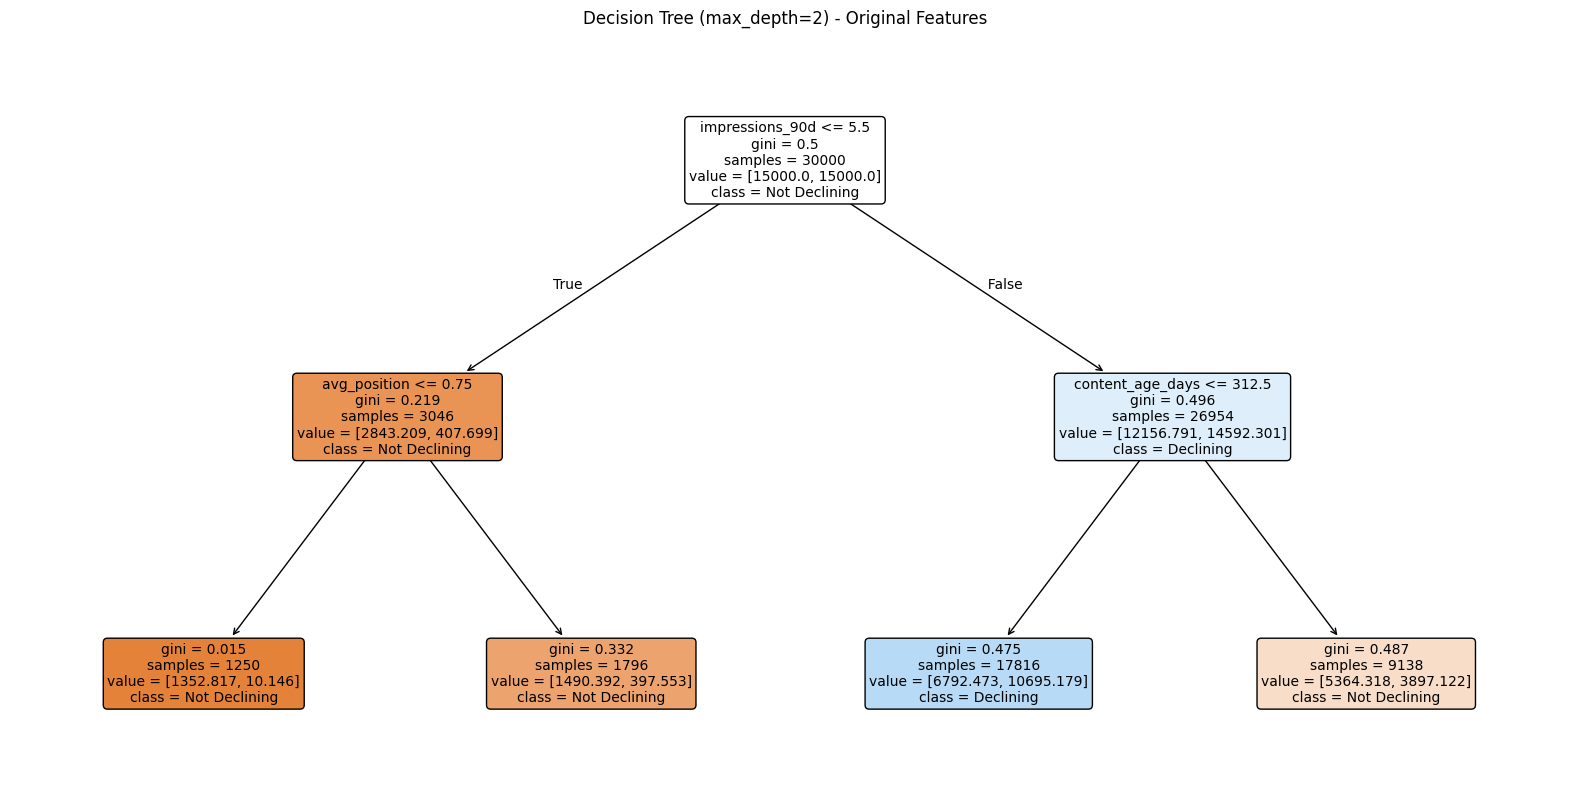


Plotting Decision Tree with max_depth=3 (original features):


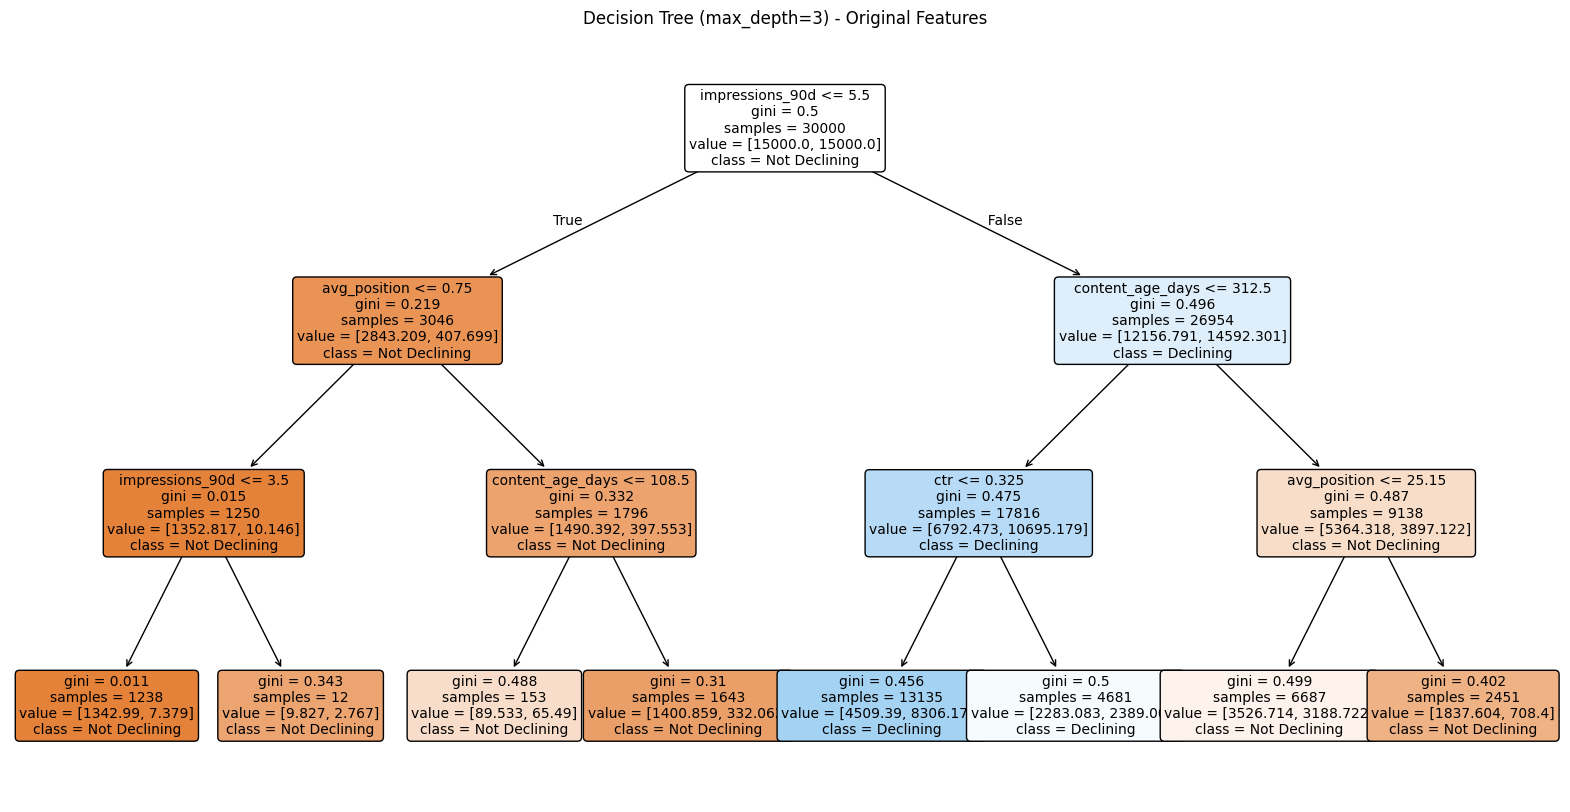


Plotting Decision Tree with max_depth=4 (original features):


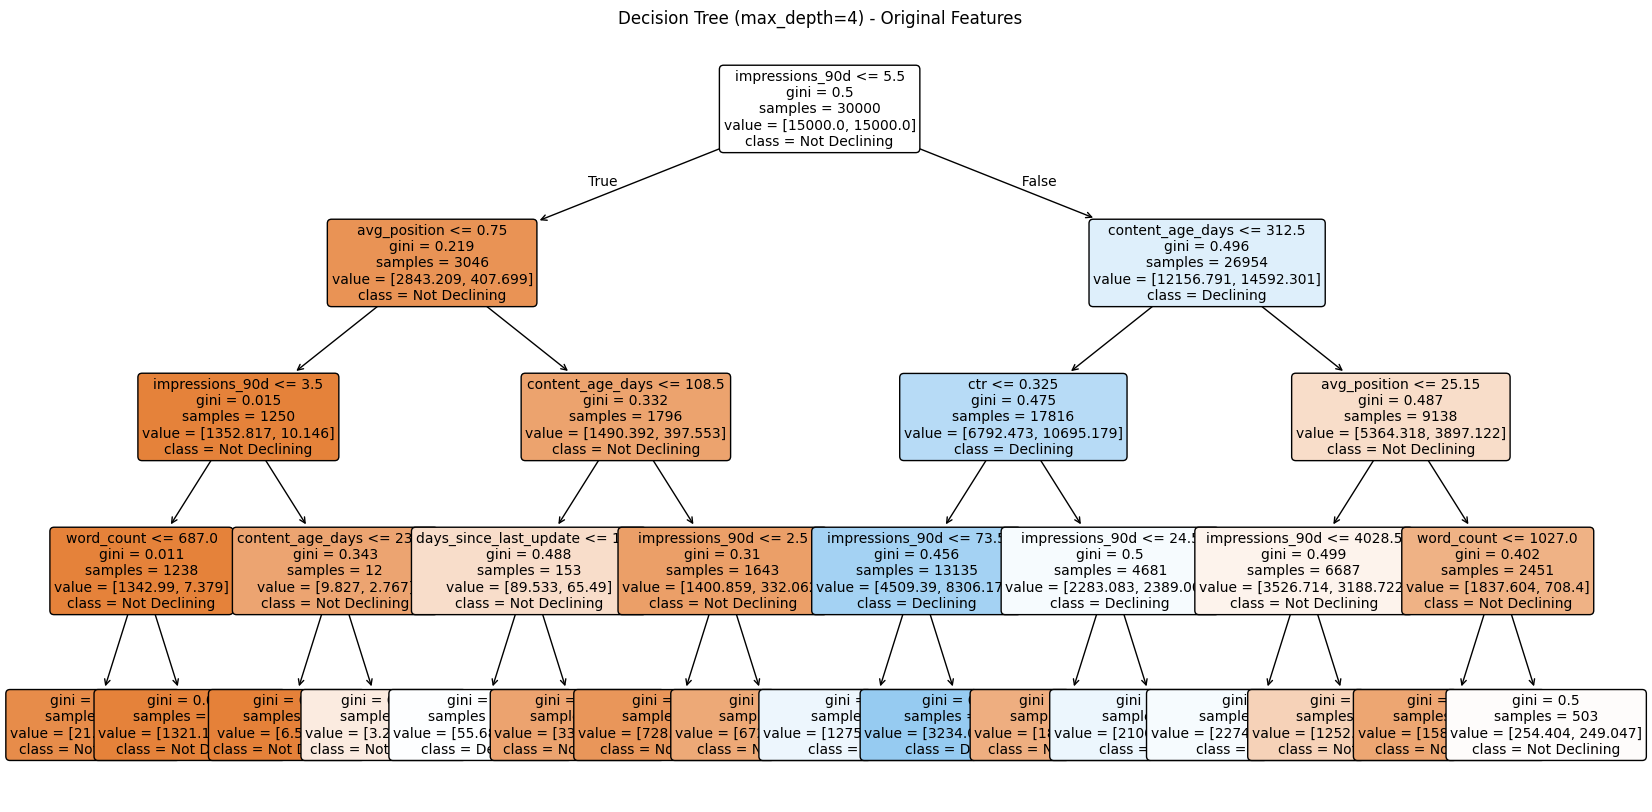


--- Visualizing Experiment 2: Swapping features (max_depth=2) ---

Plotting Decision Tree with: Original Features (max_depth=2)


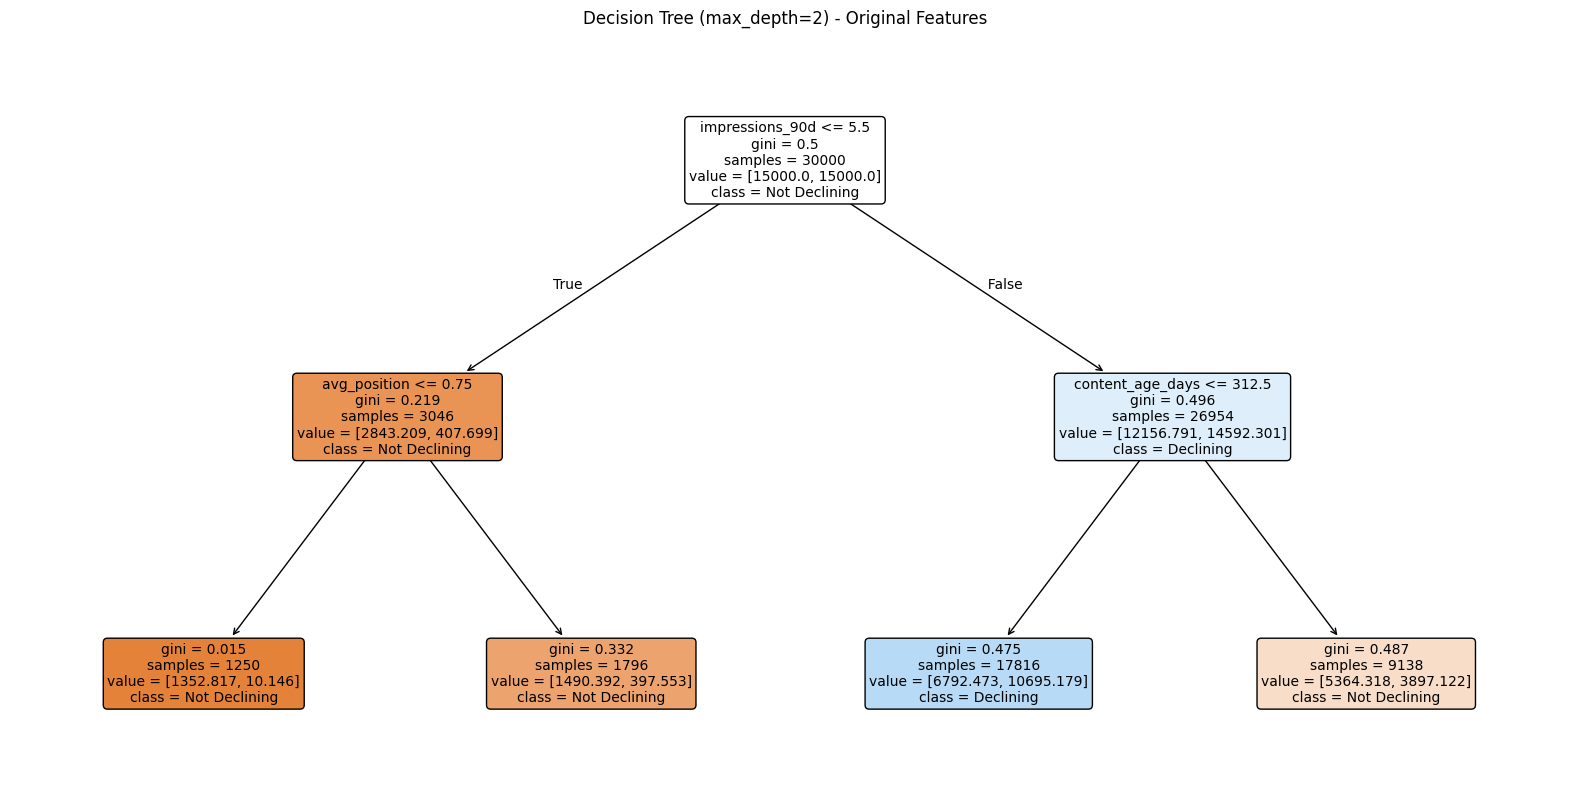


Plotting Decision Tree with: Features without impressions_90d (max_depth=2)


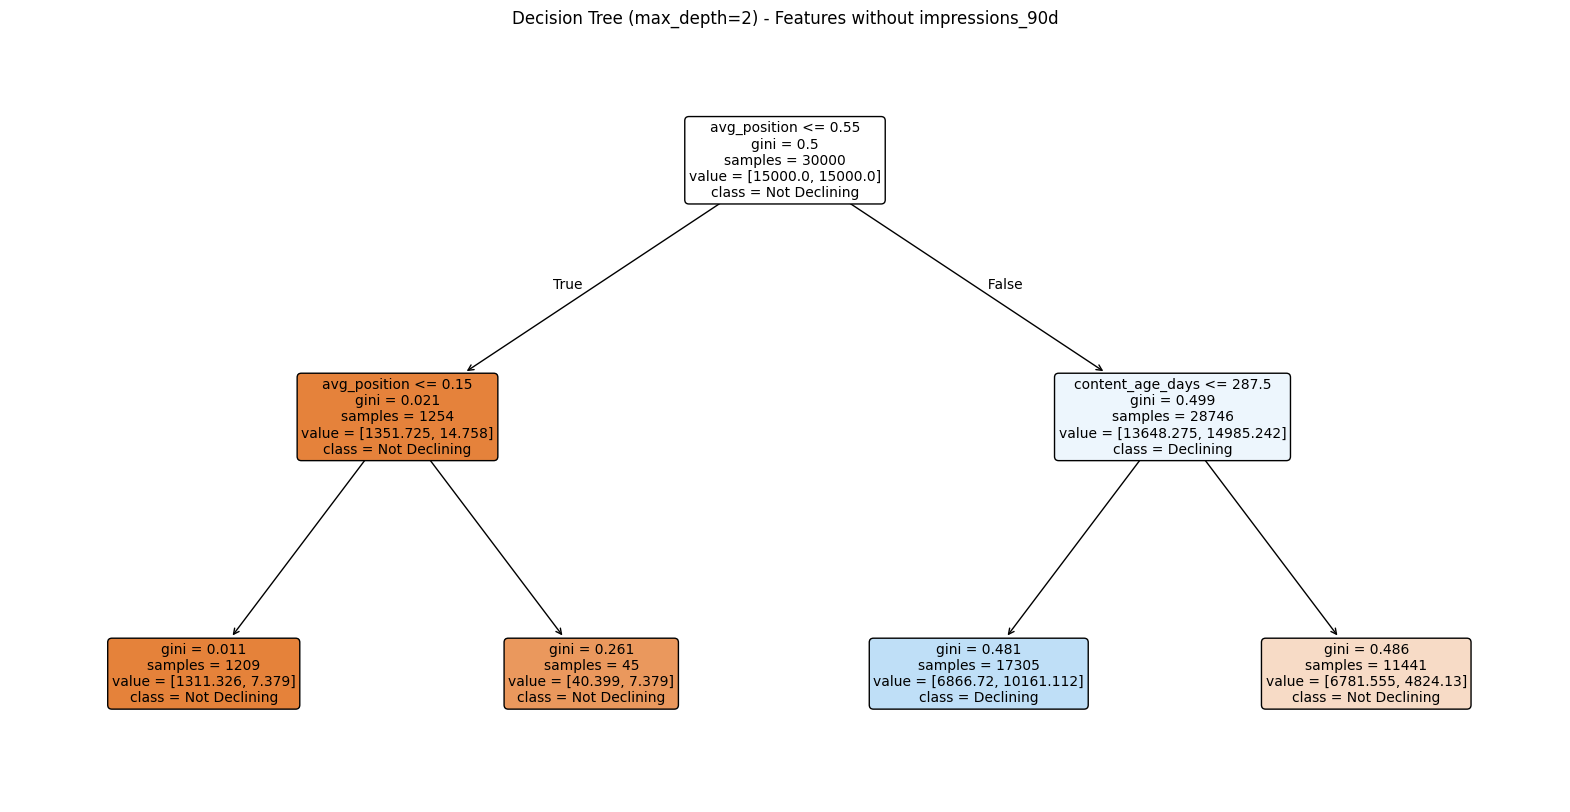


Plotting Decision Tree with: Features with engagement_rate (replacing impressions_90d) (max_depth=2)


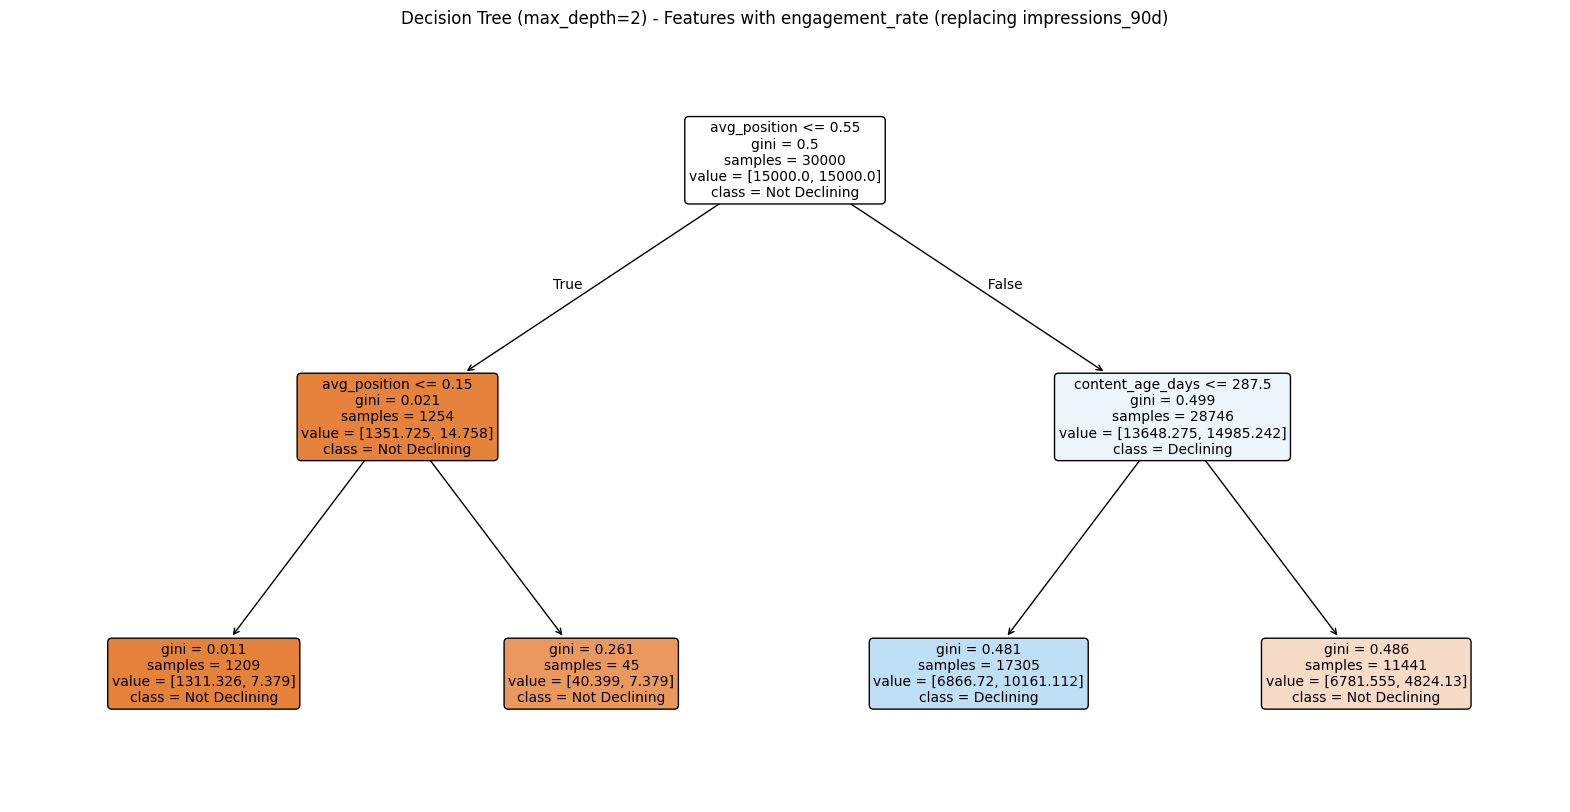


--- End of Visualizations ---


In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Assuming `y` and `df` are already defined from previous cells
# Assuming `precision_at_k` is defined

original_features = [
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "avg_position",
    "ctr",
    "word_count"
]
X_original = df[original_features].replace([np.inf, -np.inf], np.nan).fillna(0)

print("--- Visualizing Experiment 1: Varying max_depth with original features ---")

for depth in [2, 3, 4]:
    print(f"\nPlotting Decision Tree with max_depth={depth} (original features):")
    tree_clf = DecisionTreeClassifier(max_depth=depth, class_weight="balanced", random_state=42)
    tree_clf.fit(X_original, y)

    plt.figure(figsize=(20, 10)) # Adjust figure size for better readability
    plot_tree(tree_clf, filled=True, feature_names=original_features, class_names=['Not Declining', 'Declining'], rounded=True, fontsize=10)
    plt.title(f"Decision Tree (max_depth={depth}) - Original Features")
    plt.show()

print("\n--- Visualizing Experiment 2: Swapping features (max_depth=2) ---")

# Ensure engagement_rate is created if it was used in the previous experiment cell
if 'engagement_rate' not in df.columns:
    df['engagement_rate'] = df['ctr'] * 100

feature_sets_to_test = {
    "Original Features": original_features,
    "Features without impressions_90d": [f for f in original_features if f != "impressions_90d"]
}
features_with_engagement = [f for f in original_features if f != "impressions_90d"] + ["engagement_rate"]
feature_sets_to_test["Features with engagement_rate (replacing impressions_90d)"] = features_with_engagement

for name, current_features in feature_sets_to_test.items():
    print(f"\nPlotting Decision Tree with: {name} (max_depth=2)")
    X_current = df[current_features].replace([np.inf, -np.inf], np.nan).fillna(0)

    tree_clf = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42)
    tree_clf.fit(X_current, y)

    plt.figure(figsize=(20, 10)) # Adjust figure size
    plot_tree(tree_clf, filled=True, feature_names=current_features, class_names=['Not Declining', 'Declining'], rounded=True, fontsize=10)
    plt.title(f"Decision Tree (max_depth=2) - {name}")
    plt.show()

print("\n--- End of Visualizations ---")

### Save your work
**Colab:** *File → Save a copy in GitHub* (your submission) and *File → Save a copy in Drive*.

You now have the two core reflexes of applied ML: **discover before you model**, and **prefer a model you can read and can't fool**. That's the whole foundation the capstone builds on.